In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skimage as sk
from skimage import data, io
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
from skimage.color import label2rgb
from skimage import exposure

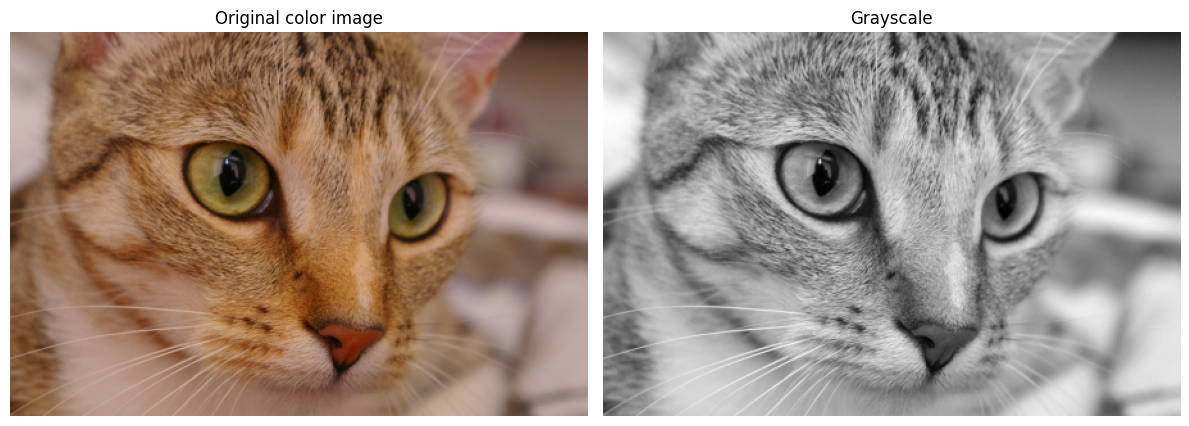

In [2]:
from skimage.data import binary_blobs
import skimage as sk

IC = sk.data.chelsea()  # RGB color image

IG = sk.color.rgb2gray(IC)  # convert RGB to grayscale

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(IC)
axes[0].set_title('Original color image')
axes[0].axis('off')
axes[1].imshow(IG, cmap='gray')
axes[1].set_title('Grayscale')
axes[1].axis('off')
plt.tight_layout()
plt.show()

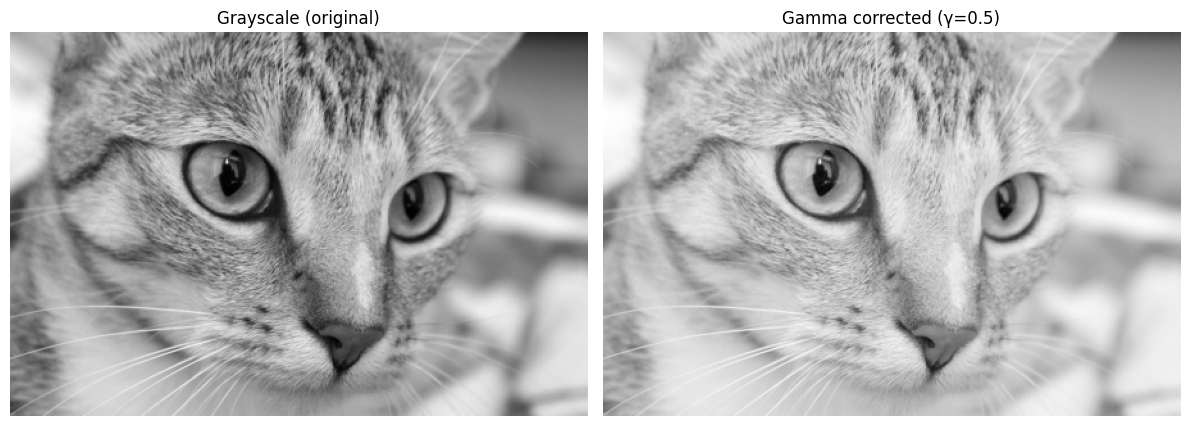

In [3]:
IG_gamma = exposure.adjust_gamma(IG, 0.5)  # gamma = 0.5 brightens the image

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(IG, cmap='gray')
axes[0].set_title('Grayscale (original)')
axes[0].axis('off')
axes[1].imshow(IG_gamma, cmap='gray')
axes[1].set_title('Gamma corrected (γ=0.5)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

Otsu threshold value: 0.4447


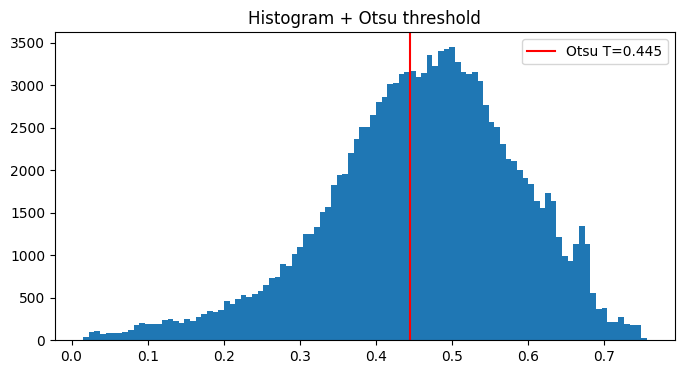

In [4]:
thresh = threshold_otsu(IG)  # compute threshold on original grayscale
print('Otsu threshold value: {:.4f}'.format(thresh))

flat_data = IG.flatten()
fig = plt.figure(figsize=(8, 4))
plt.hist(flat_data, bins=100)
plt.axvline(thresh, color='r', label=f'Otsu T={thresh:.3f}')
plt.title('Histogram + Otsu threshold')
plt.legend()
plt.show()

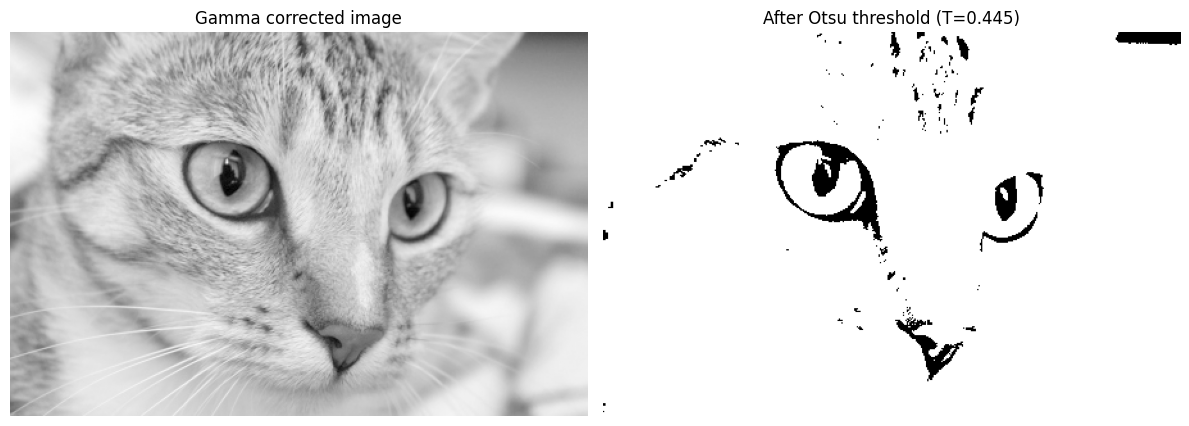

In [5]:
bw = IG_gamma > thresh  # apply threshold computed on original to gamma-corrected image

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(IG_gamma, cmap='gray')
axes[0].set_title('Gamma corrected image')
axes[0].axis('off')
axes[1].imshow(bw, cmap='gray')
axes[1].set_title('After Otsu threshold (T={:.3f})'.format(thresh))
axes[1].axis('off')
plt.tight_layout()
plt.show()

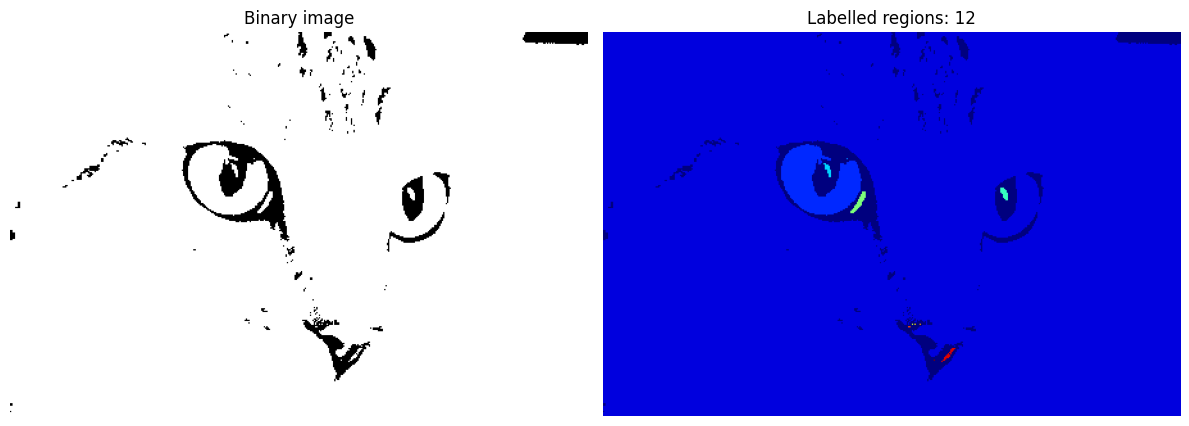

In [6]:
label_image, nregions = label(bw, return_num=True)  # label connected regions

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(bw, cmap='gray')
axes[0].set_title('Binary image')
axes[0].axis('off')
axes[1].imshow(label_image, cmap='jet')
axes[1].set_title('Labelled regions: {}'.format(nregions))
axes[1].axis('off')
plt.tight_layout()
plt.show()

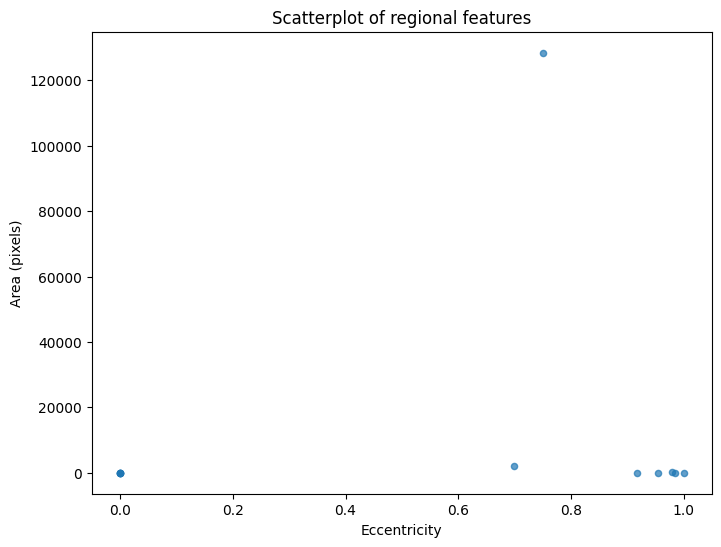

In [7]:
props = regionprops(label_image)  # get all region properties

area = np.array([p.area for p in props])           # area of each region
eccentricity = np.array([p.eccentricity for p in props])  # eccentricity (0=circle, 1=line)

# scatterplot of features
fig = plt.figure(figsize=(8, 6))
plt.scatter(eccentricity, area, s=20, alpha=0.7)
plt.xlabel('Eccentricity')
plt.ylabel('Area (pixels)')
plt.title('Scatterplot of regional features')
plt.show()

In [8]:
# balloons are roundish (low eccentricity) and large (high area)
balloon_mask = (area > 500) & (eccentricity < 0.8)
balloon_labels = np.array([props[i].label for i in range(len(props)) if balloon_mask[i]])

print('Number of balloons found: {}'.format(len(balloon_labels)))
print('Balloon labels: {}'.format(balloon_labels))

Number of balloons found: 2
Balloon labels: [1 2]


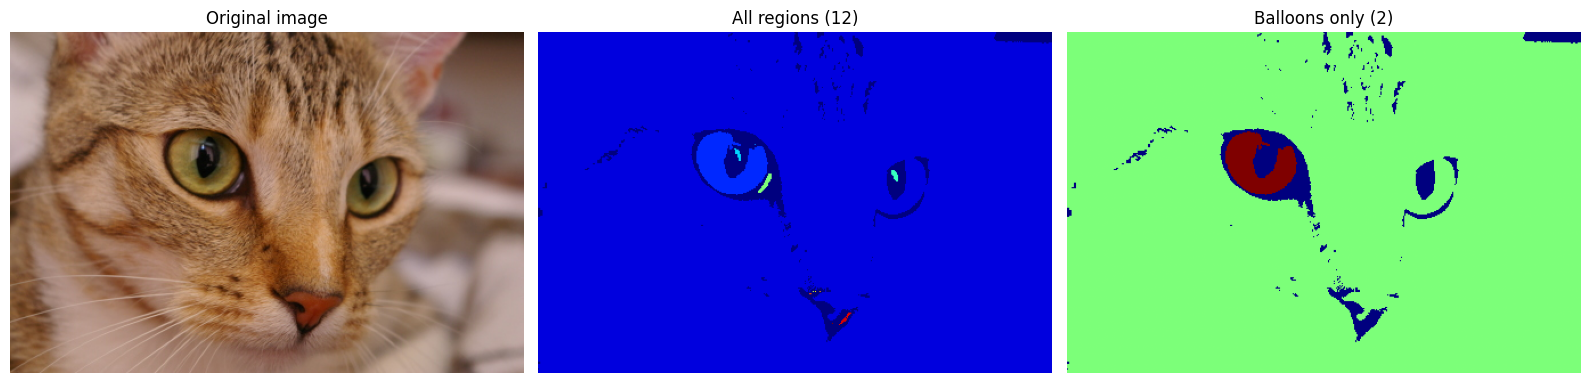

In [9]:
# create a mask with only balloon regions
balloon_image = np.zeros_like(label_image)
for lbl in balloon_labels:
    balloon_image[label_image == lbl] = lbl  # keep only balloon regions

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(IC)
axes[0].set_title('Original image')
axes[0].axis('off')
axes[1].imshow(label_image, cmap='jet')
axes[1].set_title('All regions ({})'.format(nregions))
axes[1].axis('off')
axes[2].imshow(balloon_image, cmap='jet')
axes[2].set_title('Balloons only ({})'.format(len(balloon_labels)))
axes[2].axis('off')
plt.tight_layout()
plt.show()